In [1]:
#install required packages
!pip install imblearn
!pip install mapie
!pip install ISLP
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder,RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize)
from ISLP import confusion_table
import warnings
warnings.filterwarnings('ignore')
from keras.models import Model
from keras.layers import Input, Dense
import xgboost as xgb
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, Recall
from mapie.classification import MapieClassifier
from keras.models import Model
from keras.layers import Input, Dense, Dropout
from keras.callbacks import EarlyStopping

from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import ADASYN, SMOTENC, SMOTE
from imblearn.pipeline import Pipeline as ImbalancedPipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import  balanced_accuracy_score


In [2]:

# load and explore dataset
#df = pd.read_csv("/content/creditcard.csv")
df = pd.read_csv("../data/creditcard.csv")
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.shape

(284807, 31)

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.isnull().sum().max() #determine if null values exist

0

In [7]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

<Axes: >

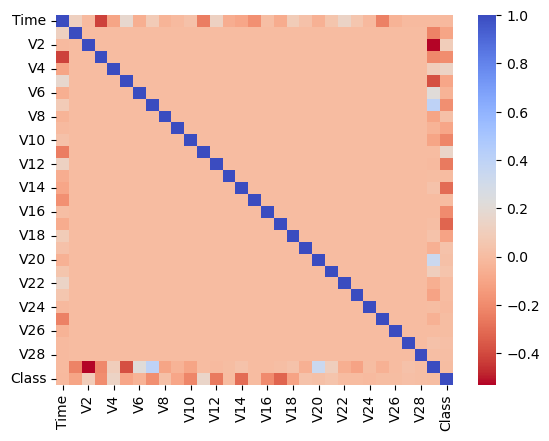

In [8]:
# Entire DataFrame
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20})

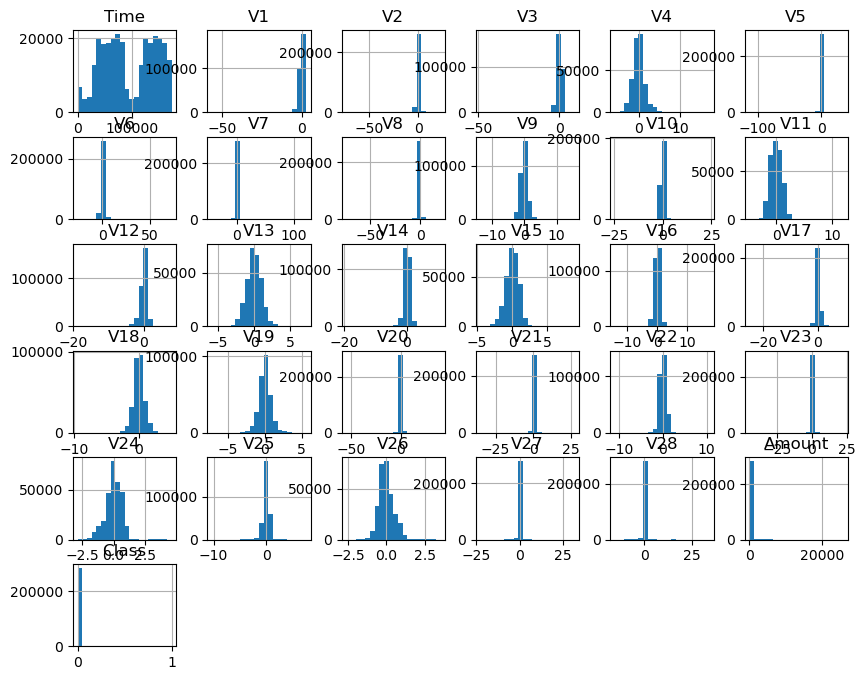

In [9]:
df.hist(bins=20, figsize=(10, 8))
plt.show()

In [10]:
# Determine number of fraud cases in dataset
fraud = df[df['Class'] == 1]
valid = df[df['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(df[df['Class'] == 1])))
print('Valid Transactions: {}'.format(len(df[df['Class'] == 0])))
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')
print('Amount details of the fraudulent transaction')
fraud.Amount.describe()
print('details of valid transaction')
valid.Amount.describe()

0.0017304750013189597
Fraud Cases: 492
Valid Transactions: 284315
No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset
Amount details of the fraudulent transaction
details of valid transaction


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

We split the dataset into training and calibration sets, ensuring that the target variable is stratified to maintain the proportion of the two classes.
Next, we define multiple pipelines with different sampling techniques (SMOTE, ADASYN, SMOTENC) and classifiers. Fit these models to the training data and determine which gives us the best results

In [11]:
# Assuming 'Class' is the target column and the rest are features
X = df.drop('Class', axis=1)
y = df['Class']

y.dropna(inplace=True)
X = X.loc[y.index]  # Align X with the dropped rows in y
# Automatically determine numeric and categorical columns before converting X to NumPy
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Split the dataset
X_train_stratify, X_test_stratify, y_train_stratify, y_test_stratify = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
# Define pipelines for numeric and categorical features
pipe_num = Pipeline([
    ('imputer', KNNImputer(n_neighbors=7, weights='distance')),
    ('standardizer', RobustScaler())
])

pipe_cat = Pipeline([
    ('simple_imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='infrequent_if_exist', drop='if_binary'))
])

transformer = ColumnTransformer(
    transformers=[
        ('num_transforms', pipe_num, num_cols),
        ('cat_transforms', pipe_cat, cat_cols)
    ],
    remainder='drop'
)

# Define the pipeline with SMOTE
pipe1 = ImbalancedPipeline(
    steps=[
        ('preproc', transformer),
        ('sampler', SMOTE(random_state=42)),  # Add SMOTE for data augmentation
        ('classifier', RandomForestClassifier())
    ]
)

# Define the pipeline with BalancedRandomForestClassifier
pipe2 = Pipeline(
    steps=[
        ('preproc', transformer),
        ('classifier', BalancedRandomForestClassifier(random_state=42))  # Replace with BalancedRandomForestClassifier
    ]
)

# Define the pipeline with ADASYN
pipe3 = ImbalancedPipeline(
    steps=[
        ('preproc', transformer),
        ('sampler', ADASYN(random_state=42)),  # Replace SMOTE with ADASYN
        ('classifier', RandomForestClassifier())
    ]
)


In [13]:
# Define the pipeline without any of these techniques
pipe4 = Pipeline(
    steps=[
        ('preproc', transformer),
        ('classifier', RandomForestClassifier())
    ])

In [14]:
pipe1

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=7,
                                                                              weights='distance')),
                                                                  ('standardizer',
                                                                   RobustScaler())]),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='infrequent_if_exist'))]),
                                                  [])])),
                ('sampler', SMOTE(random_state=42)),
                ('classifier', RandomForestClassifier())])

In [15]:
pipe2

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=7,
                                                                              weights='distance')),
                                                                  ('standardizer',
                                                                   RobustScaler())]),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='infrequent_if_exist'))]),
                                                  [])])),
                ('classifier',
                 BalancedRandomForestClassifier(random_state=42))])

In [16]:
pipe3

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=7,
                                                                              weights='distance')),
                                                                  ('standardizer',
                                                                   RobustScaler())]),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='infrequent_if_exist'))]),
                                                  [])])),
                ('sampler', ADASYN(random_state=42)),
                ('classifier', RandomForestClassifier())])

In [17]:
pipe4

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=7,
                                                                              weights='distance')),
                                                                  ('standardizer',
                                                                   RobustScaler())]),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='infrequent_if_exist'))]),
                                                  [])])),
                ('classifier', RandomForestClassifier())])

In [18]:
# Fit the pipeline on the training data
history1 = pipe1.fit(X_train, y_train)
history2 = pipe2.fit(X_train, y_train)
history3 = pipe3.fit(X_train, y_train)
history4 = pipe4.fit(X_train_stratify, y_train_stratify)

# Evaluate the model
score1 = pipe1.score(X_test, y_test)
score2 = pipe2.score(X_test, y_test)
score3 = pipe3.score(X_test, y_test)
score4 = pipe4.score(X_test_stratify, y_test_stratify)
print(f'Accuracy on the test set SMOTE: {score1:.2f} ')
print(f'Accuracy on the test set BALANCED RF: {score2:.2f}' )
print(f'Accuracy on the test set ADASYN: {score3:.2f}' )
print(f'Accuracy on the test set with stratify: {score4:.2f} ')

Accuracy on the test set SMOTE: 1.00 
Accuracy on the test set BALANCED RF: 0.97
Accuracy on the test set ADASYN: 1.00
Accuracy on the test set with stratify: 1.00 


Remove Balanced RF pipe3 as the other pipes are performing better and continue with other pipes

In [25]:
scoring = ['accuracy', 'f1', 'recall']

cv_scores_pipe1 = cross_validate(pipe1, X_train, y_train, cv=5, scoring=scoring)

# Accessing the scores for each metric
accuracy_scores = cv_scores_pipe1['test_accuracy']
f1_scores = cv_scores_pipe1['test_f1']
recall_scores = cv_scores_pipe1['test_recall']

accuracy_scores, f1_scores, recall_scores


(array([0.99945138, 0.99947333, 0.99940749, 0.99949527, 0.99951722]),
 array([0.8427673 , 0.83333333, 0.82352941, 0.84768212, 0.85714286]),
 array([0.85897436, 0.75949367, 0.79746835, 0.81012658, 0.83544304]))

In [26]:

cv_scores_pipe3 = cross_validate(pipe3, X_train, y_train, cv=5, scoring=scoring)

# Accessing the scores for each metric
accuracy_scores = cv_scores_pipe3['test_accuracy']
f1_scores = cv_scores_pipe3['test_f1']
recall_scores = cv_scores_pipe3['test_recall']

accuracy_scores, f1_scores, recall_scores


(array([0.99947333, 0.99945138, 0.99938555, 0.99956111, 0.99947333]),
 array([0.84810127, 0.82758621, 0.81578947, 0.86486486, 0.84615385]),
 array([0.85897436, 0.75949367, 0.78481013, 0.81012658, 0.83544304]))

In [27]:

cv_scores_pipe4 = cross_validate(pipe4, X_train, y_train, cv=5, scoring=scoring)

# Accessing the scores for each metric
accuracy_scores = cv_scores_pipe4['test_accuracy']
f1_scores = cv_scores_pipe4['test_f1']
recall_scores = cv_scores_pipe4['test_recall']

accuracy_scores, f1_scores, recall_scores


(array([0.99951722, 0.99945138, 0.99947333, 0.99956111, 0.99958305]),
 array([0.84722222, 0.81481481, 0.82857143, 0.86111111, 0.8707483 ]),
 array([0.78205128, 0.69620253, 0.73417722, 0.78481013, 0.81012658]))

Pipeline 1 (SMOTE) , Pipeline 3 (ADASYN) and Pipeline 4 (stratify) appears to be the consistent in achieving high accuracy across different folds. But the Recall seems to be higher for the pipeline with  Stratify


f1_score: 0.8842105263157894


<Figure size 800x600 with 0 Axes>

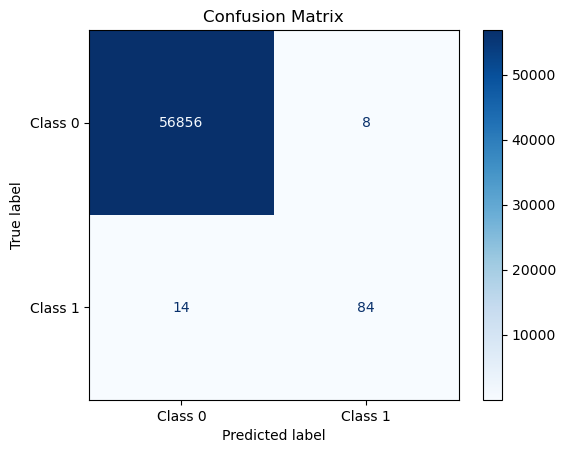

In [31]:
# Make predictions on the test data
y_pred = pipe1.predict(X_test)

# Compute f1_score and the confusion matrix
print(f"f1_score: {f1_score(y_test,y_pred)}")
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()

f1_score: 0.8645833333333334


<Figure size 800x600 with 0 Axes>

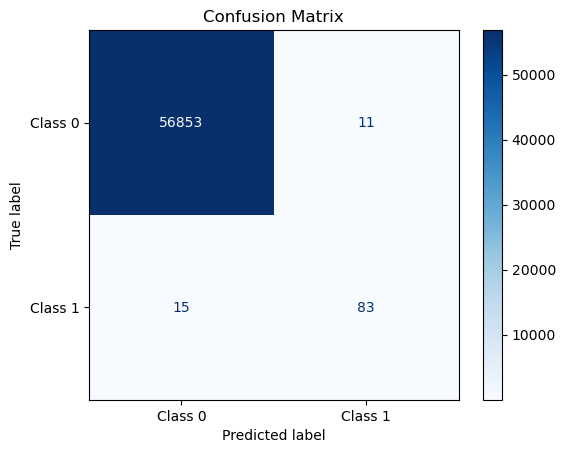

In [32]:
# Make predictions on the test data
y_pred = pipe3.predict(X_test)

# Compute f1_score and the confusion matrix
print(f"f1_score: {f1_score(y_test,y_pred)}")
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()

f1_score: 0.968421052631579


<Figure size 800x600 with 0 Axes>

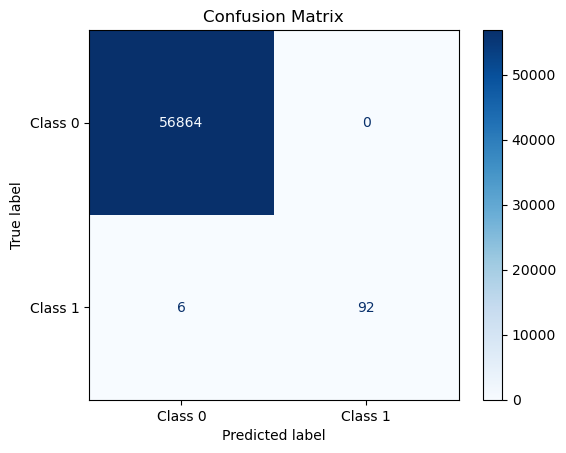

In [33]:
# Make predictions on the test data
y_pred = pipe4.predict(X_test)

# Compute f1_score and the confusion matrix
print(f"f1_score: {f1_score(y_test,y_pred)}")
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()

Pipe 4 with stratify and Random forest gives the best results with a higher f1 score and better.

In [34]:
# Create a DataFrame with the input features, true labels, and predicted labels
results_df = X_test.copy()  # Copy the input features
results_df['True_Label'] = y_test
results_df['Predicted_Label'] = y_pred

# Display the first few rows of the DataFrame
print(results_df.head())

            Time         V1        V2         V3        V4         V5  \
43428    41505.0 -16.526507  8.584972 -18.649853  9.505594 -13.793819   
49906    44261.0   0.339812 -2.743745  -0.134070 -1.385729  -1.451413   
29474    35484.0   1.399590 -0.590701   0.168619 -1.029950  -0.539806   
276481  167123.0  -0.432071  1.647895  -1.669361 -0.349504   0.785785   
278846  168473.0   2.014160 -0.137394  -1.015839  0.327269  -0.182179   

              V6         V7        V8        V9  ...       V22       V23  \
43428  -2.832404 -16.701694  7.517344 -8.507059  ... -1.127670 -2.358579   
49906   1.015887  -0.524379  0.224060  0.899746  ... -0.942525 -0.526819   
29474   0.040444  -0.712567  0.002299 -0.971747  ...  0.168269 -0.166639   
276481 -0.630647   0.276990  0.586025 -0.484715  ...  0.873663 -0.178642   
278846 -0.956571   0.043241 -0.160746  0.363241  ... -0.616400  0.347045   

             V24       V25       V26       V27       V28  Amount  True_Label  \
43428   0.673461 -1.4137